In [17]:
%load_ext autoreload
%autoreload 2

import os
# os.environ["CUDA_VISIBLE_DEVICES"]="5"

import torch
torch.backends.cudnn.benchmark = True
from torchvision import transforms, utils
from PIL import Image
import math
import random
import os

import numpy as np
from torch import nn, autograd, optim
from torch.nn import functional as F
from torch.utils import data
from tqdm import tqdm
from copy import deepcopy
import lpips
from model_ae import *
from dataset import *
torch.manual_seed(3913)
from matplotlib import pyplot as plt
import cv2
from id_loss import *
import arcface
import util
import degradations

class IDLoss(nn.Module):
    def __init__(self):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')
        self.facenet = Backbone(input_size=112, num_layers=50, drop_ratio=0.6, mode='ir_se')
        self.facenet.load_state_dict(torch.load('../RIS/model_ir_se50.pth'))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        for module in [self.facenet, self.face_pool]:
            for param in module.parameters():
                param.requires_grad = False

    def extract_feats(self, x):
        if x.size(-1) != 256:
            x = F.interpolate(x, size=(256,256), mode='area')
        x = x[:, :, 35:223, 32:220]  # Crop interesting region
        x = self.face_pool(x)
        x_feats = self.facenet(x)
        return x_feats

    def encode(self, y):
        y_feats = self.extract_feats(y)  # Otherwise use the feature from there
        return y_feats

    def forward(self, y_hat, y):
        n_samples = y.shape[0]
        y_feats = self.extract_feats(y)  # Otherwise use the feature from there
        y_hat_feats = self.extract_feats(y_hat)
        y_feats = y_feats.detach()
        loss = 0
        count = 0
        for i in range(n_samples):
            diff_target = y_hat_feats[i].dot(y_feats[i])
            loss += 1 - diff_target
            count += 1

        return loss / count



def display_image(image, size=None, mode='nearest', unnorm=False, title=''):
    # image is [3,h,w] or [1,3,h,w] tensor [0,1]
    if image.is_cuda:
        image = image.cpu()
    if size is not None and image.size(-1) != size:
        image = F.interpolate(image, size=(size,size), mode=mode)
    if image.dim() == 4:
        image = image[0]
    image = ((image.clamp(-1,1)+1)/2).permute(1, 2, 0).detach().numpy()
    plt.figure()
    plt.title(title)
    plt.axis('off')
    plt.imshow(image)

from magface import builder_inf
import math

magsafe_model = builder_inf().cuda().eval()

from curricular import IR_101

curricular_model = IR_101().cuda().eval()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
class GFPGAN_degradation(object):
    def __init__(self):
        self.kernel_list = ['iso', 'aniso']
        self.kernel_prob = [0.5, 0.5]
        self.blur_kernel_size = 41
        self.blur_sigma = [10, 10]
        self.downsample_range = [32,32]
        self.noise_range = [10, 10]
        self.jpeg_range = [80, 80]
        self.gray_prob = 0.
        self.color_jitter_prob = 0.0
        self.color_jitter_pt_prob = 0.0
        self.shift = 20/255.
    
    def degrade_process(self, img_gt):
#         if np.random.uniform() > 0.5:
#             img_gt = cv2.flip(img_gt, 1)

        h, w = img_gt.shape[:2]
       
        # random color jitter 
        if np.random.uniform() < self.color_jitter_prob:
            jitter_val = np.random.uniform(-self.shift, self.shift, 3).astype(np.float32)
            img_gt = img_gt + jitter_val
            img_gt = np.clip(img_gt, 0, 1)    

        # random grayscale
        if np.random.uniform() < self.gray_prob:
            img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2GRAY)
            img_gt = np.tile(img_gt[:, :, None], [1, 1, 3])
        
        # ------------------------ generate lq image ------------------------ #
        # blur
        kernel = degradations.random_mixed_kernels(
                self.kernel_list,
                self.kernel_prob,
                self.blur_kernel_size,
                self.blur_sigma,
                self.blur_sigma, [-math.pi, math.pi],
                noise_range=None)
        img_lq = cv2.filter2D(img_gt, -1, kernel)
        # downsample
        scale = np.random.uniform(self.downsample_range[0], self.downsample_range[1])
        img_lq = cv2.resize(img_lq, (int(w // scale), int(h // scale)), interpolation=cv2.INTER_LINEAR)
        
        # noise
        if self.noise_range is not None:
            img_lq = degradations.random_add_gaussian_noise(img_lq, self.noise_range)
        # jpeg compression
        if self.jpeg_range is not None:
            img_lq = degradations.random_add_jpg_compression(img_lq, self.jpeg_range)

        # round and clip
        img_lq = np.clip((img_lq * 255.0).round(), 0, 255) / 255.

        # resize to original size
        img_lq = cv2.resize(img_lq, (w, h), interpolation=cv2.INTER_LINEAR)

        return img_gt, img_lq


In [19]:
latent_dim = 512
n_sample = 8
device = 'cuda'
size = 1024

generator = Denoiser(size, 512, 8, channel_multiplier=2).to(device).eval()
ckpt = torch.load('./latest.pt', map_location=lambda storage, loc: storage)
generator.load_state_dict(ckpt["g"], strict=True)


id_encoder = IDLoss().to(device).eval()
arc_face = arcface.ResNetArcFace(block='IRBlock', layers=(2, 2, 2, 2), use_se=False).cuda().eval()
arc_face.load_state_dict(torch.load('arcface_resnet18.pth'), strict=True)



transform = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

degrade = GFPGAN_degradation()

def load_im(path, resolution=256, device='cuda'):
    img_gt = cv2.imread(path, cv2.IMREAD_COLOR)
    img_gt = cv2.resize(img_gt, (resolution, resolution), interpolation=cv2.INTER_AREA)

    # BFR degradation
    # We adopt the degradation of GFPGAN for simplicity, which however differs from our implementation in the paper.
    # Data degradation plays a key role in BFR. Please replace it with your own methods.
    img_gt = img_gt.astype(np.float32)/255.
    img_gt, img_lq = degrade.degrade_process(img_gt)

    img_gt =  (torch.from_numpy(img_gt) - 0.5) / 0.5
    img_lq =  (torch.from_numpy(img_lq) - 0.5) / 0.5

    img_gt = img_gt.permute(2, 0, 1).flip(0).unsqueeze(0) # BGR->RGB
    img_lq = img_lq.permute(2, 0, 1).flip(0).unsqueeze(0) # BGR->RGB

    return img_lq.to(device), img_gt.to(device)

Loading ResNet ArcFace


tensor([0.4333], device='cuda:0')


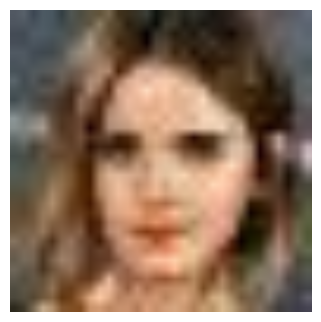

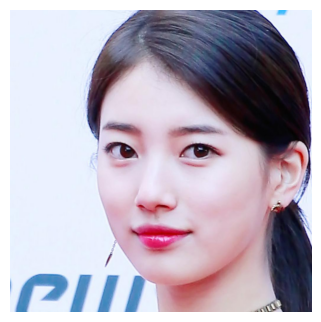

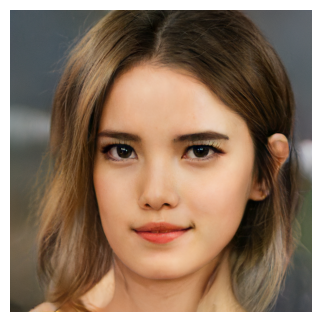

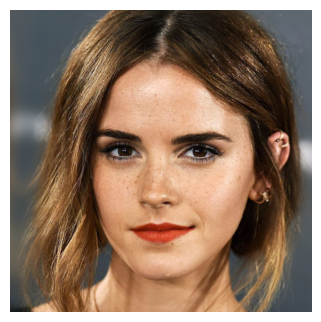

In [120]:
plt.rcParams['figure.dpi'] = 100

x1_lq, x1_hq = load_im('../SOAT/emma_aligned.png', size)
x2_lq, x2_hq = load_im('temp.jpeg', size)



target_im = x2_hq
input_im = x1_lq
input_gt = x1_hq

with torch.no_grad():
    target_id = id_encoder.encode(target_im)
    
    fake_img = generator(input_im, target_id)
    fake_id = id_encoder.encode(fake_img)


display_image(input_im)
display_image(target_im)
display_image(fake_img)
display_image(input_gt)

In [124]:
from copy import deepcopy
f_generator = deepcopy(generator)
f_generator.train()

    
g_optim = optim.Adam(f_generator.parameters(), lr=1e-4)


cos = nn.CosineSimilarity(dim=1, eps=0)

for i in tqdm(range(20)):
    fake_img = f_generator(input_im, target_id)

    # id loss
    fake_id = id_encoder.encode(fake_img.mean(1,keepdim=True).repeat(1,3,1,1)) #[B, 512]
    id_loss = 1*(1-(fake_id * target_id).sum(-1)).mean()
    g_optim.zero_grad()
    id_loss.backward()
    g_optim.step()

100%|██████████| 20/20 [00:05<00:00,  3.39it/s]


tensor([0.2666], device='cuda:0')


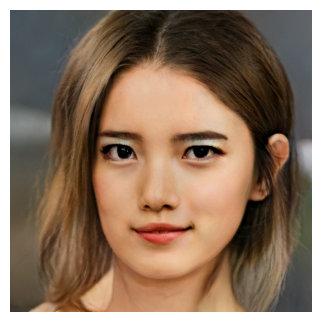

In [125]:
f_generator.eval()
with torch.no_grad():
    fake_img = f_generator(input_im, target_id)
display_image(fake_img, size=1024)

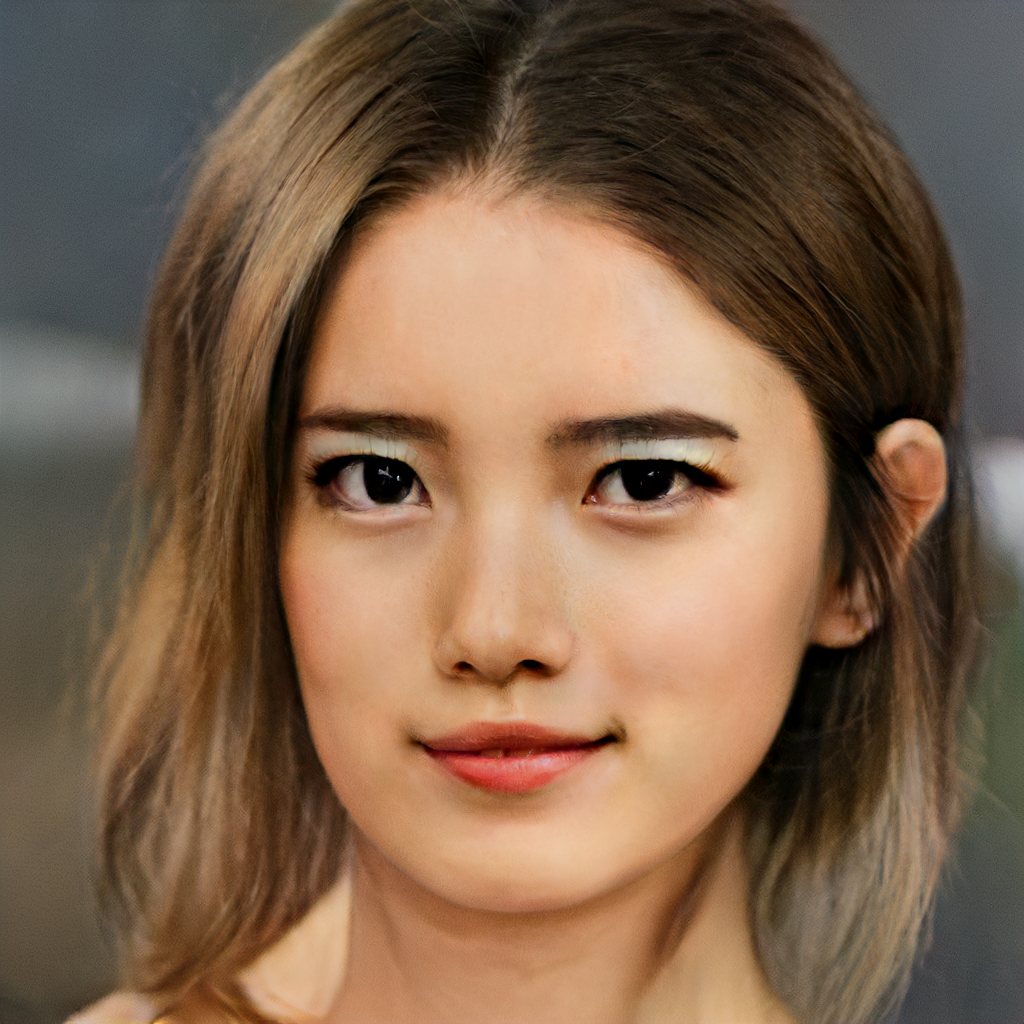

In [126]:
transforms.ToPILImage()(utils.make_grid(fake_img.cpu(), normalize=True, range=(-1, 1)))
